# Introduction & Problem Statement

**Project Title:** Bank Customer Churn Prediction  
Dataset link: https://www.kaggle.com/datasets/shantanudhakadd/bank-customer-churn-prediction

**Student:** Mohammed Awad  
**ID:** 1320225023

**Course:** Machine Learning

# **Issue dealt with**
Customer churn happens when customers stop using the bank's services. The goal of this project is to build a supervised machine learning model that predicts whether a bank customer is likely to leave the bank.

The target variable is **Exited**:

- 0 = the customer stayed
- 1 = the customer churned

This is a classification problem. The project focuses on data preprocessing, EDA, feature engineering, model training, evaluation, model comparison, and interpretation using classical machine learning algorithms.


# Importing Libraries

The project uses Pandas and NumPy for data handling, Matplotlib and Seaborn for visualization, and scikit-learn for preprocessing, model training, cross validation, and evaluation.


In [2]:
import numpy as np
import pandas as pd
#visualisation
import matplotlib.pyplot as plt
import seaborn as sns

#Scikit-learn: preprocessing & model selection
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
#Scikit-learn: classification
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
#Scikit-learn: regression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")
SEED = 42

# Dataset Description

The dataset used in this project is the **Bank Customer Churn Prediction** dataset. It contains customer information such as credit score, age, geography, gender, tenure, balance, number of products, activity status, estimated salary, and whether the customer exited the bank.

The dataset has more than 1,000 records


In [3]:
df = pd.read_csv("data/Churn_Modelling.csv")
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
print("Columns:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

print("\nTarget distribution:")
display(df['Exited'].value_counts())

display(df.describe(include='all').T)


Columns:
['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-nul

Exited
0    7963
1    2037
Name: count, dtype: int64

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
RowNumber,10000.0,NaN,NaN,NaN,5000.5,2886.89568,1.0,2500.75,5000.5,7500.25,10000.0
CustomerId,10000.0,NaN,NaN,NaN,15690940.5694,71936.186123,15565701.0,15628528.25,15690738.0,15753233.75,15815690.0
Surname,10000,2932,Smith,32,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CreditScore,10000.0,NaN,NaN,NaN,650.5288,96.653299,350.0,584.0,652.0,718.0,850.0
Geography,10000,3,France,5014,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,10000,2,Male,5457,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,10000.0,NaN,NaN,NaN,38.9218,10.487806,18.0,32.0,37.0,44.0,92.0
Tenure,10000.0,NaN,NaN,NaN,5.0128,2.892174,0.0,3.0,5.0,7.0,10.0
Balance,10000.0,NaN,NaN,NaN,76485.889288,62397.405202,0.0,0.0,97198.54,127644.24,250898.09
NumOfProducts,10000.0,NaN,NaN,NaN,1.5302,0.581654,1.0,1.0,1.0,2.0,4.0


# Data Preprocessing

In this section, I check missing values, duplicates, categorical variables, and outliers. I also create new features that may help the model understand customer behavior better.

To avoid data leakage, the train/test split is done before fitting the scaler. Outlier capping values and scaling parameters are learned from the training data only and then applied to the test data.


In [5]:
# Work on a copy to keep the original data unchanged
working_df = df.copy()

print("Missing values per column:")
display(working_df.isnull().sum())

print("\nDuplicated rows:", working_df.duplicated().sum())


Missing values per column:


RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


Duplicated rows: 0


In [6]:
# Remove duplicated rows
working_df = working_df.drop_duplicates().copy()

# Drop ID/name columns because they do not provide meaningful predictive information
id_columns = ['RowNumber', 'CustomerId', 'Surname']
working_df = working_df.drop(columns=[col for col in id_columns if col in working_df.columns])

print("Shape after removing duplicates and ID columns:", working_df.shape)
working_df.head()


Shape after removing duplicates and ID columns: (10000, 11)


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Feature Engineering

I created additional features to improve the model:

- **BalanceSalaryRatio:** compares the customer's bank balance with estimated salary so high value may indicate a different financial behavior.
- **TenureAgeRatio:** compares customer tenure with age giving a simple relationship between how long the customer stayed and their age.
- **HasBalance:** shows whether the customer has a positive balance or not.

These features are simple and understandable, and they are based on existing columns.


In [7]:
# Feature engineering
working_df['BalanceSalaryRatio'] = working_df['Balance'] / (working_df['EstimatedSalary'] + 1)
working_df['TenureAgeRatio'] = working_df['Tenure'] / (working_df['Age'] + 1)
working_df['HasBalance'] = (working_df['Balance'] > 0).astype(int)

working_df[['Balance', 'EstimatedSalary', 'BalanceSalaryRatio', 'Tenure', 'Age', 'TenureAgeRatio', 'HasBalance']].head()


,Balance,EstimatedSalary,BalanceSalaryRatio,Tenure,Age,TenureAgeRatio,HasBalance
0,0.00,101348.88,0.000000,2,42,0.046512,0
1,83807.86,112542.58,0.744670,1,41,0.023810,1
2,159660.80,113931.57,1.401362,8,42,0.186047,1
3,0.00,93826.63,0.000000,1,39,0.025000,0
4,125510.82,79084.10,1.587035,2,43,0.045455,1


## Outlier Detection

I used boxplots and the IQR method to detect outliers in numerical columns. for treatment, I use capping instead of deleting many rows. This keeps the dataset size stable while reducing the effect of extreme values.


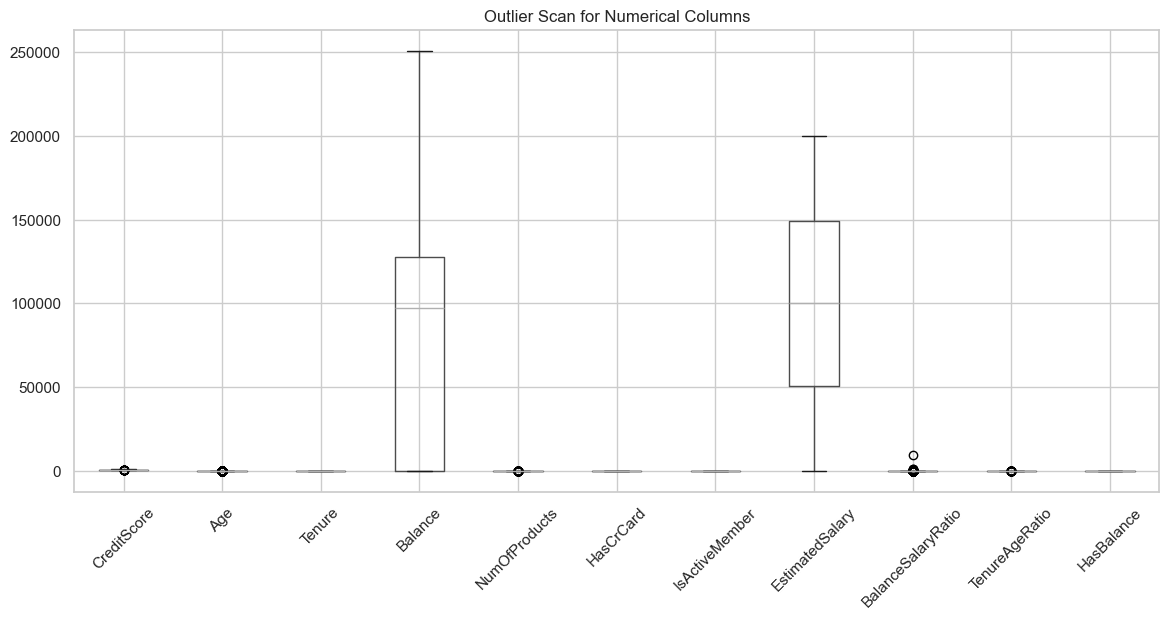

Outlier counts using IQR method:


BalanceSalaryRatio    972
Age                   359
NumOfProducts          60
TenureAgeRatio         46
CreditScore            15
Tenure                  0
Balance                 0
HasCrCard               0
IsActiveMember          0
EstimatedSalary         0
HasBalance              0
dtype: int64

In [8]:
numeric_columns = working_df.select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns.tolist()

# i dont treat the target as an outlier feature
if 'Exited' in numeric_columns:
    numeric_columns.remove('Exited')

plt.figure(figsize=(14, 6))
working_df[numeric_columns].boxplot(rot=45)
plt.title("Outlier Scan for Numerical Columns")
plt.show()

Q1 = working_df[numeric_columns].quantile(0.25)
Q3 = working_df[numeric_columns].quantile(0.75)
IQR = Q3 - Q1
outlier_counts = ((working_df[numeric_columns] < (Q1 - 1.5 * IQR)) | (working_df[numeric_columns] > (Q3 + 1.5 * IQR))).sum()

print("Outlier counts using IQR method:")
display(outlier_counts.sort_values(ascending=False))


# Exploratory Data Analysis (EDA)

This section includes statistical and visual analysis using matplotlib and seaborn. the goal is to understand distributions, class imbalance, correlations, and feature-target relationships.


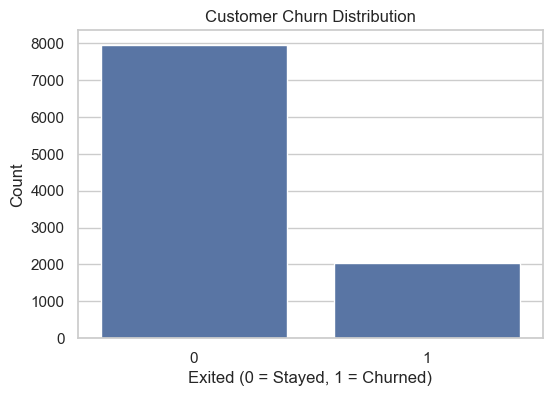

Target distribution percentage:


Exited
0    79.63
1    20.37
Name: proportion, dtype: float64

In [9]:
#target distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=working_df, x='Exited')
plt.title("Customer Churn Distribution")
plt.xlabel("Exited (0 = Stayed, 1 = Churned)")
plt.ylabel("Count")
plt.show()

print("Target distribution percentage:")
display((working_df['Exited'].value_counts(normalize=True) * 100).round(2))


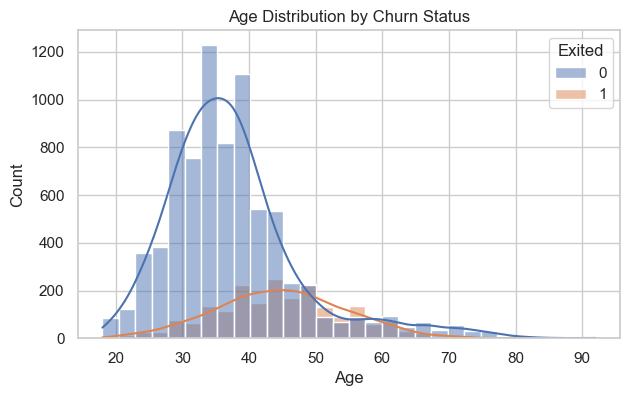

In [10]:
#distribution plot for age
plt.figure(figsize=(7, 4))
sns.histplot(data=working_df, x='Age', hue='Exited', kde=True, bins=30)
plt.title("Age Distribution by Churn Status")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()


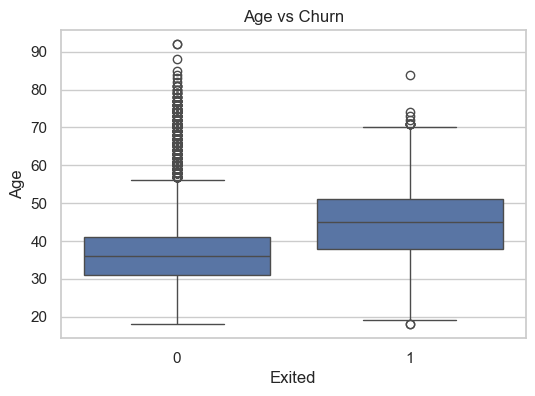

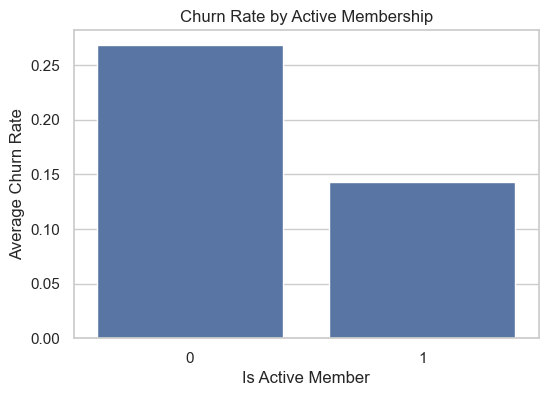

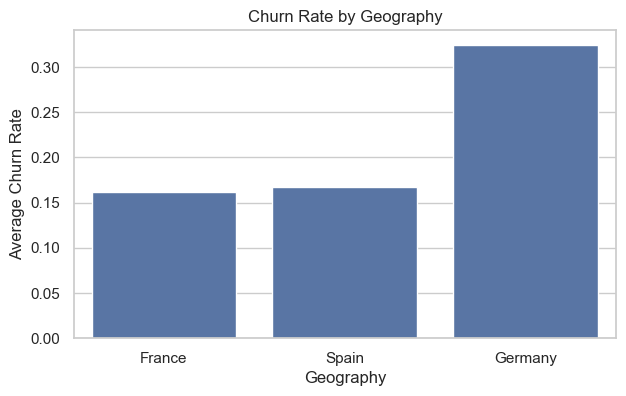

In [11]:
#feature-target relationship: Age vs Exited
plt.figure(figsize=(6, 4))
sns.boxplot(data=working_df, x='Exited', y='Age')
plt.title("Age vs Churn")
plt.xlabel("Exited")
plt.ylabel("Age")
plt.show()

#feature-target relationship: IsActiveMember vs Exited
plt.figure(figsize=(6, 4))
sns.barplot(data=working_df, x='IsActiveMember', y='Exited', estimator=np.mean, errorbar=None)
plt.title("Churn Rate by Active Membership")
plt.xlabel("Is Active Member")
plt.ylabel("Average Churn Rate")
plt.show()

#feature-target relationship: Geography vs Exited
plt.figure(figsize=(7, 4))
sns.barplot(data=working_df, x='Geography', y='Exited', estimator=np.mean, errorbar=None)
plt.title("Churn Rate by Geography")
plt.xlabel("Geography")
plt.ylabel("Average Churn Rate")
plt.show()

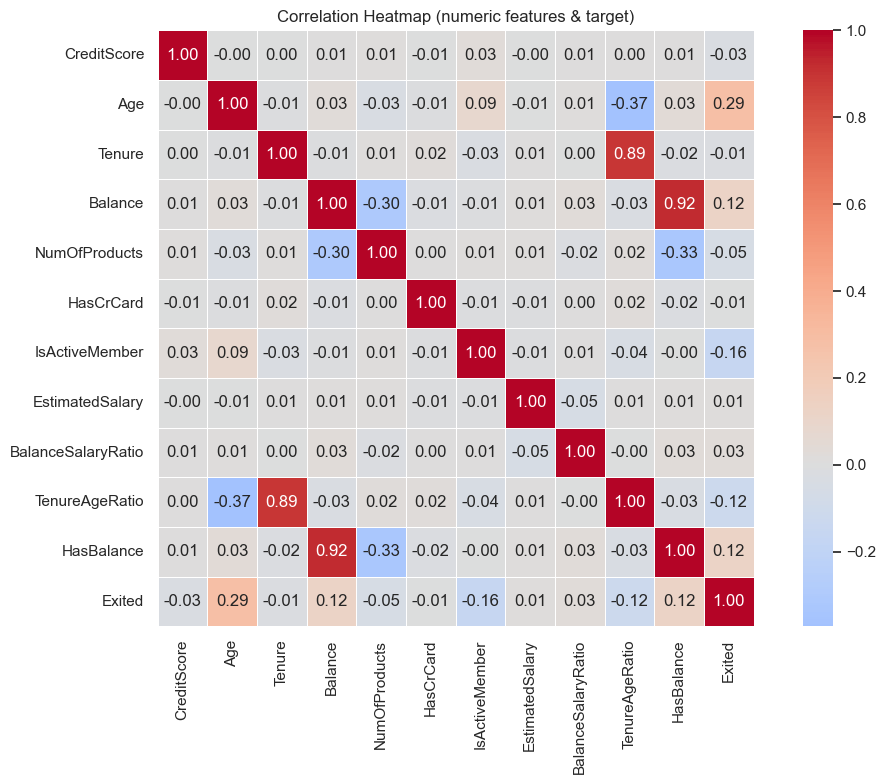

In [12]:
#correlation analysis
target = 'Exited'
corr_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
             'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
             'BalanceSalaryRatio', 'TenureAgeRatio', 'HasBalance', target]

plt.figure(figsize=(11, 8))
sns.heatmap(working_df[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Correlation Heatmap (numeric features & target)')
plt.tight_layout()
plt.show()

## EDA Insights

From the visualizations:

1. The target variable is imbalanced because fewer customers churned compared with customers who stayed.
2. Age appears related to churn. Older customers show a different churn behavior than younger customers.
3. Inactive customers generally have a higher churn rate than active customers.
4. Geography also shows differences in churn rate, which means location may help the model.

Because the target is imbalanced, I focus on **Recall** and **F1-score**, not accuracy only.


# Final data preparation for modeling

The data is split into training and testing sets. Then:

- Outlier caps are fitted on training data only.
- Categorical columns are one-hot encoded.
- Numerical features are scaled using StandardScaler fitted on training data only.

This avoids data leakage.


In [13]:
#separate features and target
X = working_df.drop(columns=['Exited'])
y = working_df['Exited'].astype(int)

#split before fitting preprocessing tools to avoid data leakage
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=SEED
)

print("Training shape:", X_train_raw.shape)
print("Testing shape:", X_test_raw.shape)
print("Training target distribution:")
display(y_train.value_counts(normalize=True).round(3))

Training shape: (8000, 13)
Testing shape: (2000, 13)
Training target distribution:


Exited
0    0.796
1    0.204
Name: proportion, dtype: float64

In [14]:
#Outlier treatment using capping based on training data only
numeric_features = X_train_raw.select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns.tolist()
categorical_features = X_train_raw.select_dtypes(include=['object']).columns.tolist()

#fit IQR bounds on training data
Q1_train = X_train_raw[numeric_features].quantile(0.25)
Q3_train = X_train_raw[numeric_features].quantile(0.75)
IQR_train = Q3_train - Q1_train
lower_bounds = Q1_train - 1.5 * IQR_train
upper_bounds = Q3_train + 1.5 * IQR_train

def cap_outliers(data, numeric_cols, lower, upper):
    capped = data.copy()
    for col in numeric_cols:
        capped[col] = capped[col].clip(lower=lower[col], upper=upper[col])
    return capped

X_train_capped = cap_outliers(X_train_raw, numeric_features, lower_bounds, upper_bounds)
X_test_capped = cap_outliers(X_test_raw, numeric_features, lower_bounds, upper_bounds)

print("Outlier capping applied using training data IQR bounds.")

Outlier capping applied using training data IQR bounds.


In [15]:
#One-hot encode categorical variables
X_train_encoded = pd.get_dummies(X_train_capped, columns=categorical_features, drop_first=True)
X_test_encoded = pd.get_dummies(X_test_capped, columns=categorical_features, drop_first=True)

#align test columns with train columns
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

#scale numeric features only, fit on train only
scaler = StandardScaler()
X_train_final = X_train_encoded.copy()
X_test_final = X_test_encoded.copy()

X_train_final[numeric_features] = scaler.fit_transform(X_train_final[numeric_features])
X_test_final[numeric_features] = scaler.transform(X_test_final[numeric_features])

print("Final training shape:", X_train_final.shape)
print("Final testing shape:", X_test_final.shape)
X_train_final.head()

Final training shape: (8000, 14)
Final testing shape: (2000, 14)


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,BalanceSalaryRatio,TenureAgeRatio,HasBalance,Geography_Germany,Geography_Spain,Gender_Male
2151,1.059320,1.879946,0.684723,-1.226059,-0.924045,0.641042,-1.030206,1.042084,-0.880464,-0.152326,-1.329364,False,False,True
8392,0.914226,-0.684468,-0.696202,0.413288,-0.924045,0.641042,-1.030206,-0.623556,0.439159,-0.500213,0.752239,True,False,True
5006,1.080048,-0.171585,-1.731895,0.601687,0.831443,0.641042,0.970680,0.308128,-0.078606,-1.562186,0.752239,True,False,False
4117,-0.930551,-0.171585,-0.005739,-1.226059,0.831443,0.641042,-1.030206,-0.290199,-0.880464,-0.025120,-1.329364,False,False,True
7182,0.427122,1.059334,0.339492,0.548318,0.831443,-1.559960,0.970680,0.135042,-0.030145,-0.160382,0.752239,True,False,True


# Model Implementation

I implemented 3 classical supervised learning models:

1. Logistic Regression
2. K-Nearest Neighbors (KNN)
3. Decision Tree

These models are part of classical machine learning and match the project requirement to use at least two supervised learning models.


In [16]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, class_weight='balanced', random_state=SEED),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=SEED),

}

models


{'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42),
 'K-Nearest Neighbors': KNeighborsClassifier(),
 'Decision Tree': DecisionTreeClassifier(class_weight='balanced', max_depth=5, random_state=42)}

# Cross Validation

I used 5-fold Stratified Cross Validation on the training data. Stratification keeps the churn/non-churn ratio similar in each fold. I used **F1-score** because the dataset is imbalanced and F1 balances precision and recall.


In [17]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_results = []

for model_name, model in models.items():
    scores = cross_val_score(model, X_train_final, y_train, cv=cv, scoring='f1')
    cv_results.append({
        'Model': model_name,
        'CV F1 Mean': scores.mean(),
        'CV F1 Std': scores.std()
    })

cv_results_df = pd.DataFrame(cv_results).sort_values(by='CV F1 Mean', ascending=False)
display(cv_results_df)


,Model,CV F1 Mean,CV F1 Std
2,Decision Tree,0.560134,0.016926
1,K-Nearest Neighbors,0.502110,0.033624
0,Logistic Regression,0.492069,0.016702


# Evaluation & Results

Each model is trained on the training set and evaluated on the test set using:

- Accuracy
- Precision
- Recall
- F1-score
- ROC AUC
- Confusion Matrix
- Classification Report

The most important metric is **F1-score**, supported by **Recall**, because the churn class is smaller and the bank should not miss too many customers who are likely to leave.


Logistic Regression
Confusion Matrix:
[[1143  450]
 [ 121  286]]


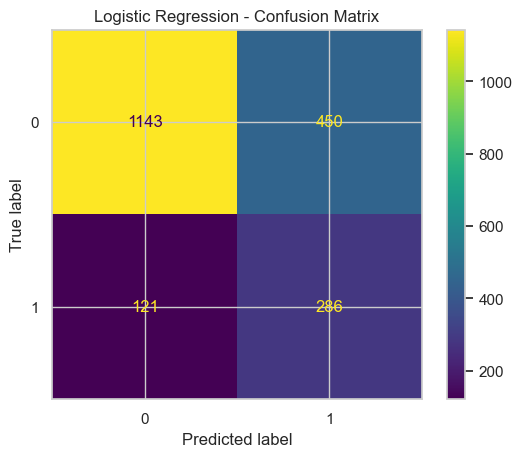


Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1593
           1       0.39      0.70      0.50       407

    accuracy                           0.71      2000
   macro avg       0.65      0.71      0.65      2000
weighted avg       0.80      0.71      0.74      2000

K-Nearest Neighbors
Confusion Matrix:
[[1515   78]
 [ 239  168]]


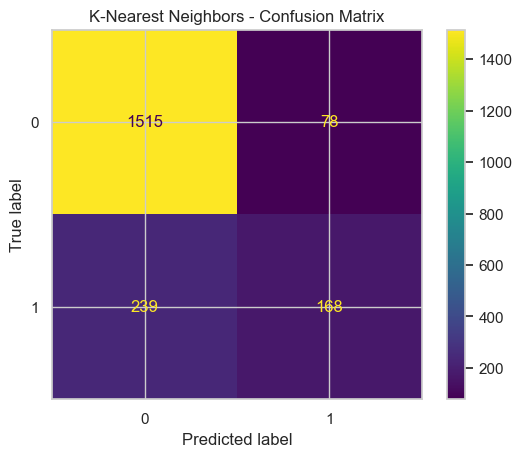


Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.95      0.91      1593
           1       0.68      0.41      0.51       407

    accuracy                           0.84      2000
   macro avg       0.77      0.68      0.71      2000
weighted avg       0.83      0.84      0.83      2000

Decision Tree
Confusion Matrix:
[[1224  369]
 [  94  313]]


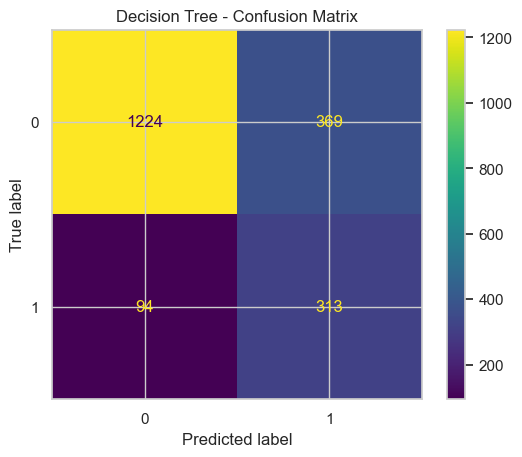


Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.77      0.84      1593
           1       0.46      0.77      0.57       407

    accuracy                           0.77      2000
   macro avg       0.69      0.77      0.71      2000
weighted avg       0.83      0.77      0.79      2000



,Model,Accuracy,Precision,Recall,F1-Score,ROC AUC
2,Decision Tree,0.7685,0.458944,0.769042,0.574839,0.838941
1,K-Nearest Neighbors,0.8415,0.682927,0.412776,0.514548,0.785662
0,Logistic Regression,0.7145,0.388587,0.702703,0.500437,0.782767


In [18]:
test_results = []
trained_models = {}

for model_name, model in models.items():
    print("=" * 70)
    print(model_name)
    print("=" * 70)

    model.fit(X_train_final, y_train)
    trained_models[model_name] = model

    y_pred = model.predict(X_test_final)

    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test_final)[:, 1]
        roc_auc = roc_auc_score(y_test, y_proba)
    else:
        roc_auc = np.nan

    test_results.append({
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1-Score': f1_score(y_test, y_pred, zero_division=0),
        'ROC AUC': roc_auc
    })

    print("Confusion Matrix:")
    cm = confusion_matrix(y_test, y_pred)
    print(cm)

    ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
    plt.title(f"{model_name} - Confusion Matrix")
    plt.show()

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

test_results_df = pd.DataFrame(test_results).sort_values(by='F1-Score', ascending=False)
display(test_results_df)


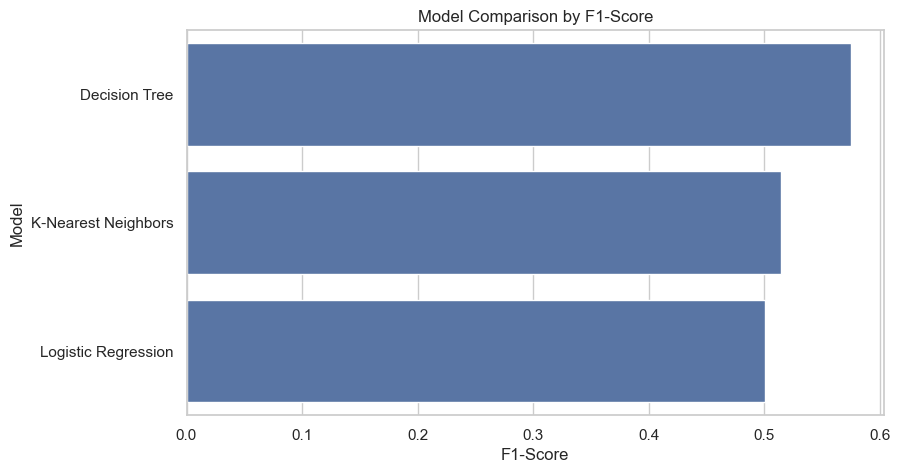

Best model based on F1-Score: Decision Tree


In [19]:
#model comparison visualization
plt.figure(figsize=(9, 5))
sns.barplot(data=test_results_df, x='F1-Score', y='Model')
plt.title("Model Comparison by F1-Score")
plt.xlabel("F1-Score")
plt.ylabel("Model")
plt.show()

best_model_name = test_results_df.iloc[0]['Model']
best_model = trained_models[best_model_name]
print("Best model based on F1-Score:", best_model_name)

# Model Interpretation

For interpretation, I used feature importance when the selected model supports it. If the best model is tree-based, the feature importance values show which features contributed most to the predictions. If the best model is Logistic Regression, the coefficient magnitudes are used instead.


Top 10 important features:


,Feature,Importance
1,Age,0.460416
4,NumOfProducts,0.344730
6,IsActiveMember,0.072108
3,Balance,0.049257
11,Geography_Germany,0.045851
8,BalanceSalaryRatio,0.016266
13,Gender_Male,0.004564
7,EstimatedSalary,0.004435
0,CreditScore,0.001555
9,TenureAgeRatio,0.000817


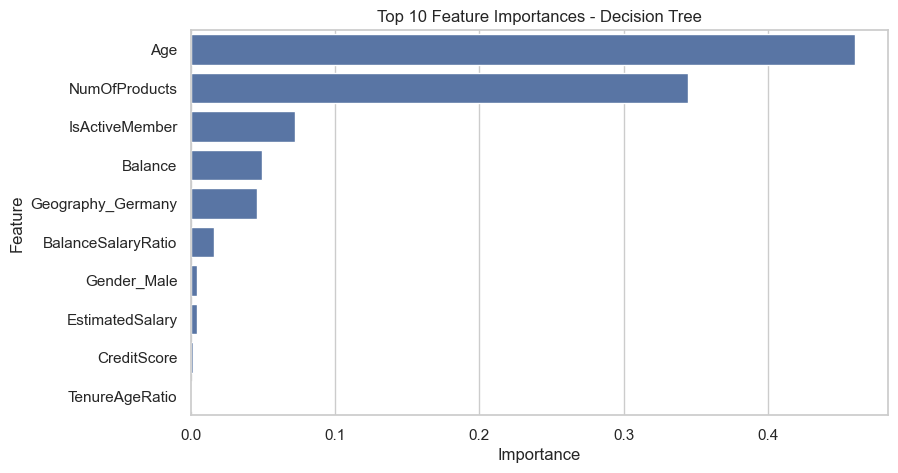

In [20]:
# Feature importance / coefficient importance
if hasattr(best_model, 'feature_importances_'):
    importance_df = pd.DataFrame({
        'Feature': X_train_final.columns,
        'Importance': best_model.feature_importances_
    }).sort_values(by='Importance', ascending=False)
else:
    importance_df = pd.DataFrame({
        'Feature': X_train_final.columns,
        'Importance': np.abs(best_model.coef_[0])
    }).sort_values(by='Importance', ascending=False)

print("Top 10 important features:")
display(importance_df.head(10))

plt.figure(figsize=(9, 5))
sns.barplot(data=importance_df.head(10), x='Importance', y='Feature')
plt.title(f"Top 10 Feature Importances - {best_model_name}")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

# Discussion & Conclusion

This project built a supervised machine learning pipeline for bank customer churn prediction.

The main steps:

1. Loading and understanding the dataset.
2. Cleaning data, checking missing values, removing duplicated rows, and treating outliers using IQR.
3. Encoding categorical variables and scaling numerical variables.
4. Performing EDA using Matplotlib and Seaborn.
5. Training and comparing multiple classical machine learning models.
6. Using cross validation and test metrics to select the best model.
7. Interpreting model behavior using feature importance.

Because the churn class is smaller, accuracy alone is not enough. F1-score and recall are more useful because they show how well the model detects customers who are likely to leave.

**Limitations:**

- The dataset may not include all real reasons why customers leave.
- Class imbalance can still make churn detection difficult.
- Some false positives and false negatives are expected.

**Real-world implication:**

A bank can use this type of model to identify customers at risk of churn and offer them better services, support, or retention offers before they leave.
